In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_excel("Flight_Fare.xlsx")


# Basic checks

In [3]:
data.shape

(10683, 11)

In [4]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
data.describe(include=object)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [7]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [8]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

# Data cleaning

In [9]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [10]:
data.dropna(inplace=True)

In [11]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(220)

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.duplicated().sum()

np.int64(0)

# EDA

# Univariate analysis

In [15]:
data['Airline'].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

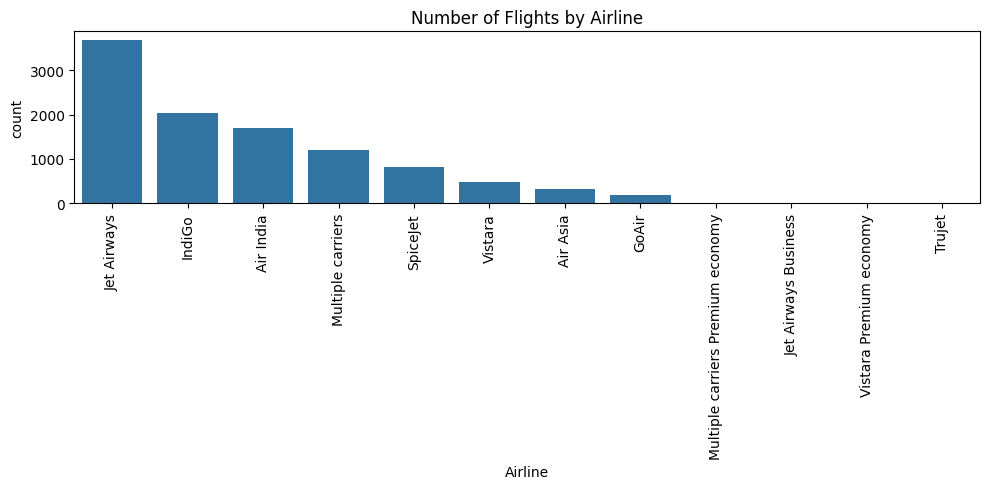

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='Airline', data=data, order=data['Airline'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of Flights by Airline')
plt.tight_layout()
plt.show()


## Insights
From this we came to know that more people travel via Jet Airways and IndiGo airlines.

In [17]:
data['Price'].describe()

count    10462.000000
mean      9026.790289
std       4624.849541
min       1759.000000
25%       5224.000000
50%       8266.000000
75%      12344.750000
max      79512.000000
Name: Price, dtype: float64

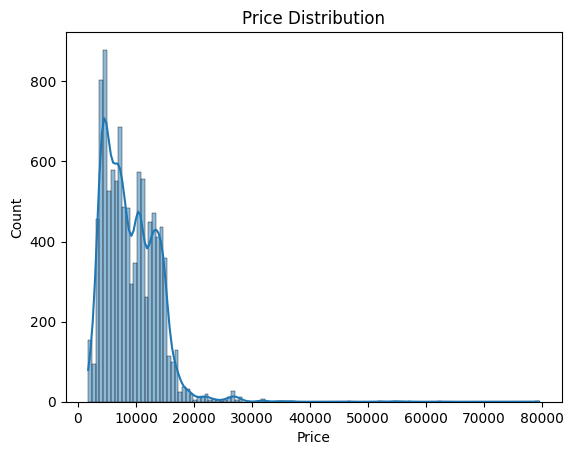

In [18]:
sns.histplot(data['Price'], kde=True)
plt.title('Price Distribution')
plt.show()


In [19]:
data['Route'].value_counts().head(10)

Route
DEL → BOM → COK    2376
BLR → DEL          1536
CCU → BOM → BLR     979
CCU → BLR           724
BOM → HYD           621
CCU → DEL → BLR     565
BLR → BOM → DEL     402
MAA → CCU           381
DEL → HYD → COK     326
DEL → BLR → COK     232
Name: count, dtype: int64

In [20]:
data['Route'].value_counts().tail(10)

Route
BOM → UDR → DEL → HYD          1
BOM → JLR → HYD                1
BOM → JDH → JAI → DEL → HYD    1
BOM → BLR → CCU → BBI → HYD    1
CCU → RPR → HYD → BLR          1
CCU → VTZ → BLR                1
CCU → IXZ → MAA → BLR          1
BOM → COK → MAA → HYD          1
BOM → CCU → HYD                1
BOM → BBI → HYD                1
Name: count, dtype: int64

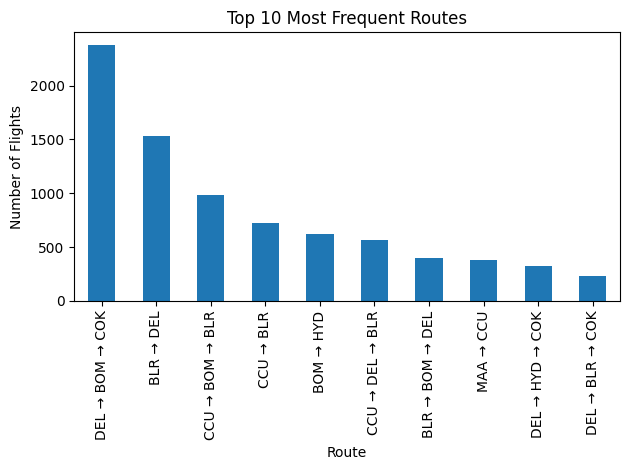

In [21]:
data['Route'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.title('Top 10 Most Frequent Routes')
plt.tight_layout()
plt.show()


In [22]:
data['Source'].value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [23]:
data['Destination'].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [24]:
data.groupby(['Source', 'Destination']).size().sort_values(ascending=False)

Source    Destination
Delhi     Cochin         4345
Kolkata   Banglore       2860
Banglore  Delhi          1265
          New Delhi       914
Mumbai    Hyderabad       697
Chennai   Kolkata         381
dtype: int64

In [25]:
print(data['Source'].unique())
data['Destination'].unique()


['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']


array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [26]:
# FIXED: scoped replace (global .replace() risked touching other columns)
data['Destination'] = data['Destination'].replace('Delhi', 'New Delhi')
data['Source'] = data['Source'].replace('Delhi', 'New Delhi')


# Insights
- There is no flight starting from Cochin by the airlines in this dataset.
- There is no destination to Chennai by the airlines in this dataset.
- From Delhi to Cochin, more travels happen via Bombay (Mumbai).

# Bivariate analysis

## Airline vs Price

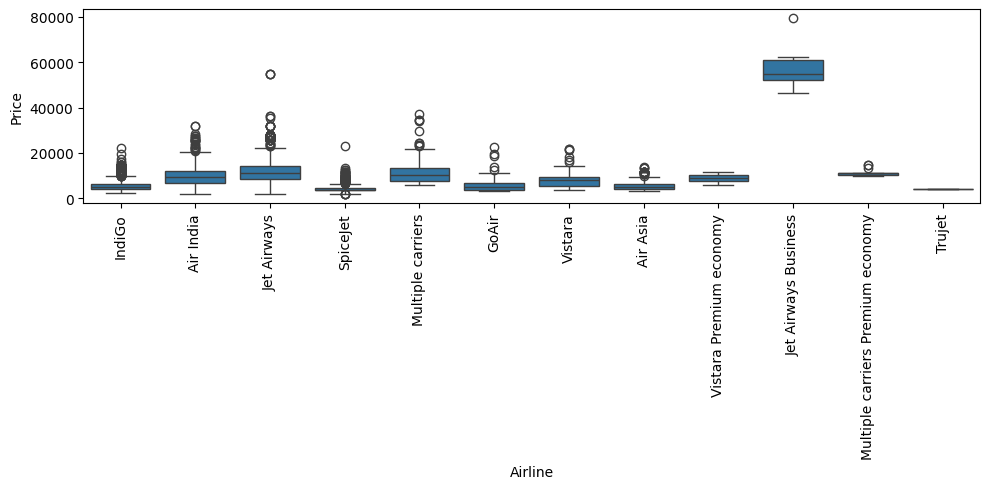

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Airline', y='Price', data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


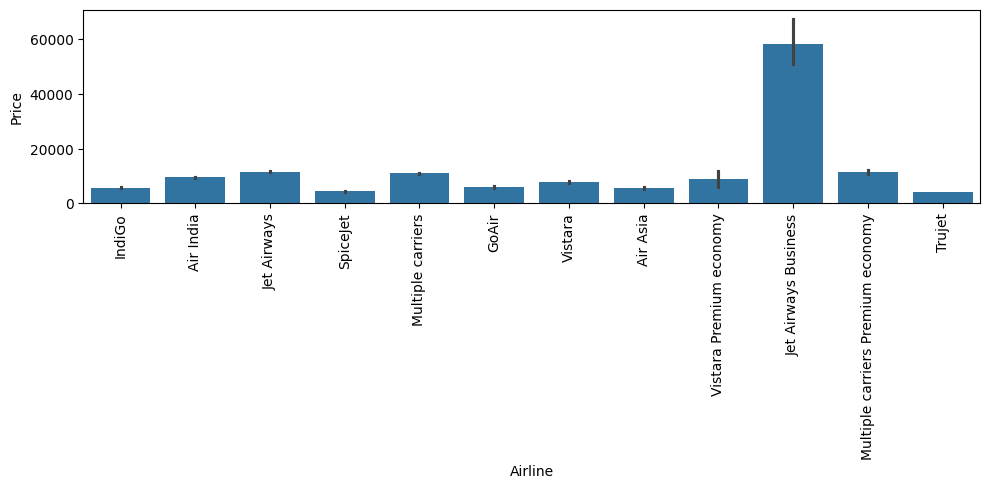

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(x='Airline', y='Price', data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Insights
Airline choice strongly influences price.
- Jet Airways Business is the most expensive among all airlines.
- Jet Airways (non-business) also has comparatively high prices.
- IndiGo, SpiceJet and GoAir are the least expensive.
- Many outliers exist, likely due to premium bookings, seasonal demand, etc.

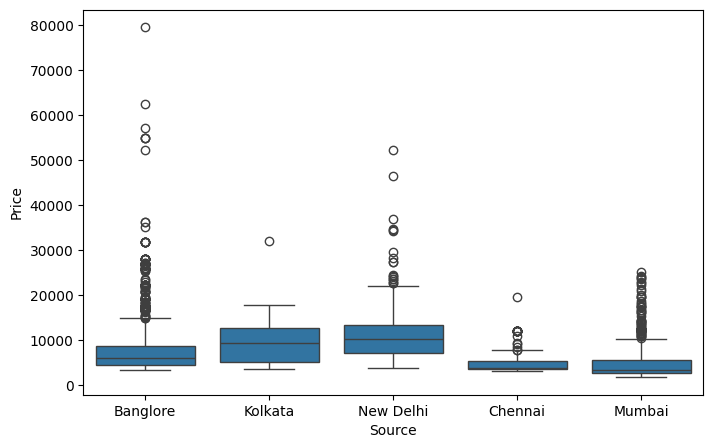

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Source', y='Price', data=data)
plt.show()


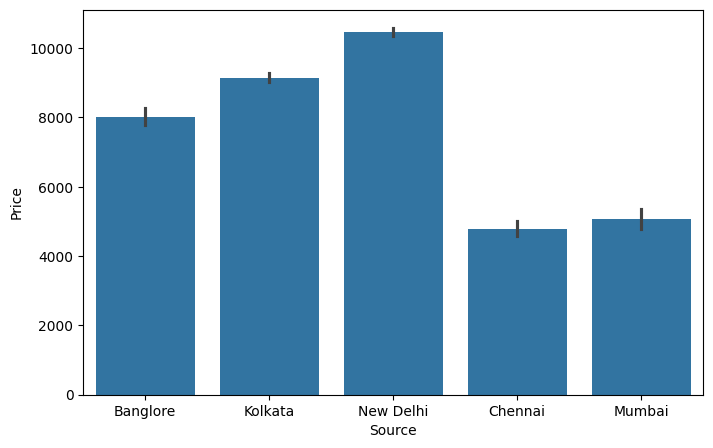

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x='Source', y='Price', data=data)
plt.show()


# Insights
Source influences price significantly.
- From Delhi and Kolkata, airline prices are higher.
- From Chennai, airline prices are lower.

In [31]:
data['Date_of_Journey'] = pd.to_datetime(data['Date_of_Journey'], dayfirst=True)
data['Journey_Day'] = data['Date_of_Journey'].dt.day
data['Journey_Month'] = data['Date_of_Journey'].dt.month

# FIXED: Date_of_Journey has no time component, so extracting .dt.hour from it
# always returns 0 and made the original Dep_Hour vs Price chart meaningless.
# Dep_Hour must come from the Dep_Time column instead.
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour


In [32]:
avg_price = data.groupby('Dep_Hour')['Price'].mean()
avg_price

Dep_Hour
0      7615.075000
1      4354.621622
2      8419.974227
3     10474.625000
4      7266.520710
5      9480.309278
6      8252.195556
7      8485.902665
8     10073.923631
9      9559.092551
10     8870.728653
11     9296.739206
12     9251.573034
13     8998.725061
14     9816.409901
15     7687.410658
16    10330.783080
17     8710.355588
18    10043.981859
19     8344.700368
20     9683.838213
21     8450.296524
22     7765.975871
23     8487.338346
Name: Price, dtype: float64

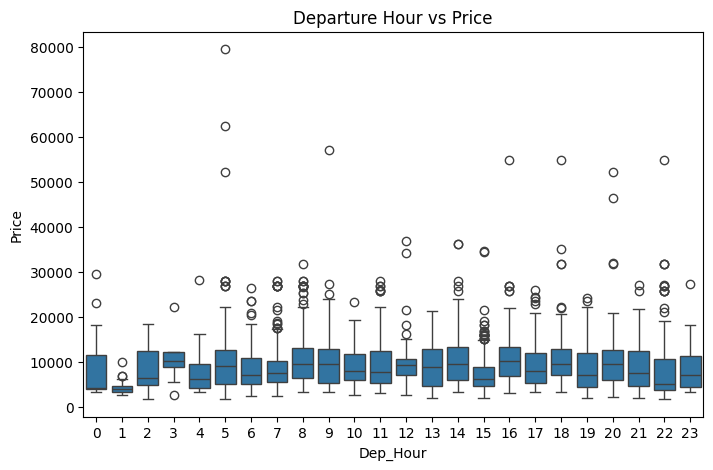

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dep_Hour', y='Price', data=data)
plt.title('Departure Hour vs Price')
plt.show()


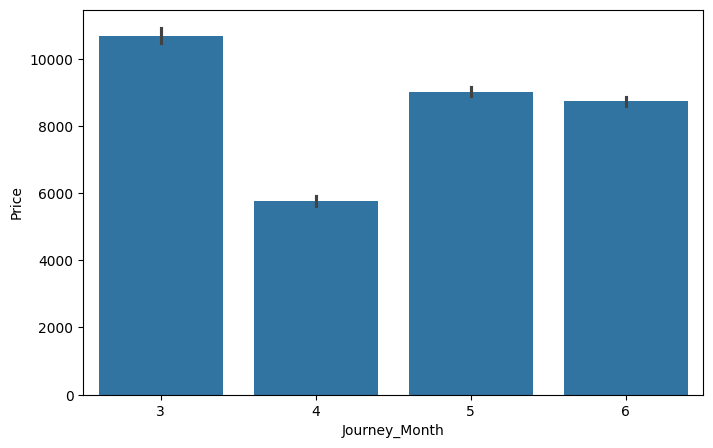

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x='Journey_Month', y='Price', data=data)
plt.show()


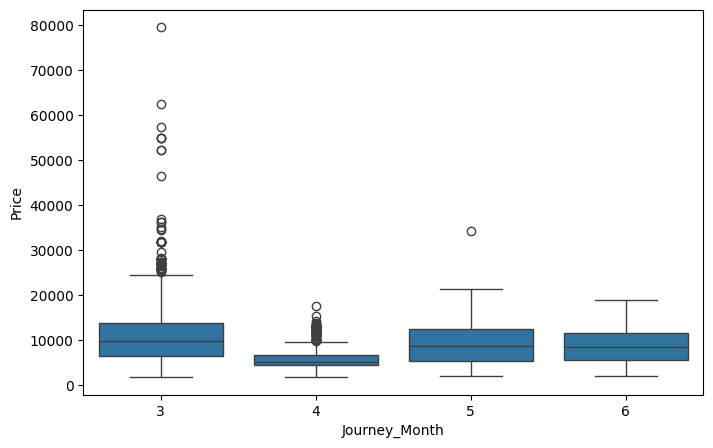

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Journey_Month', y='Price', data=data)
plt.show()


# Insights
- Month 3 (March) shows the highest average price.
- Month 4 (April) shows the lowest average price.

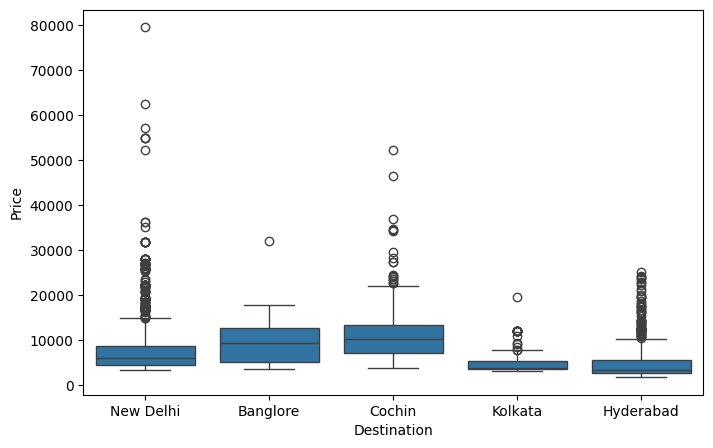

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Destination', y='Price', data=data)
plt.show()


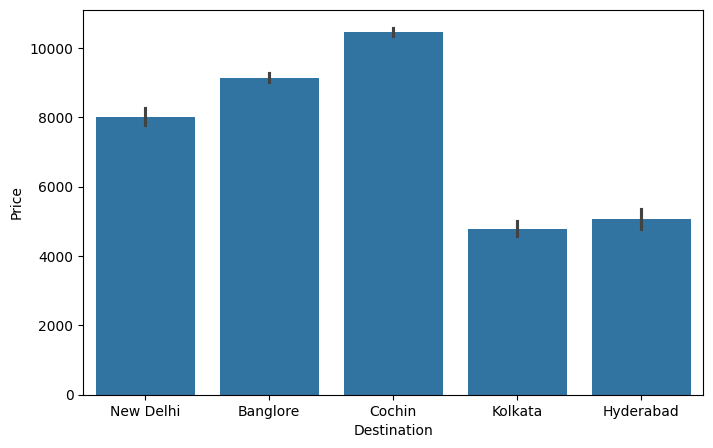

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x='Destination', y='Price', data=data)
plt.show()


# Insights
- Destination Cochin is the most expensive.
- Destination Kolkata is the least expensive.

# To analyze Duration vs Price, we first convert duration text to minutes

In [38]:
def convert_duration(duration):
    """
    Converts strings like '2h 50m', '19h', or '45m' into total minutes.
    FIXED: original version broke on durations with only hours (e.g. '19h')
    because it assumed a space-separated minute token would always exist.
    """
    duration = duration.strip()
    hours = 0
    minutes = 0

    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1].strip()

    if 'm' in duration:
        minutes = int(duration.split('m')[0].strip())

    return hours * 60 + minutes

data['Duration_Minutes'] = data['Duration'].apply(convert_duration)


In [39]:
data['Duration_Minutes'].dtype

dtype('int64')

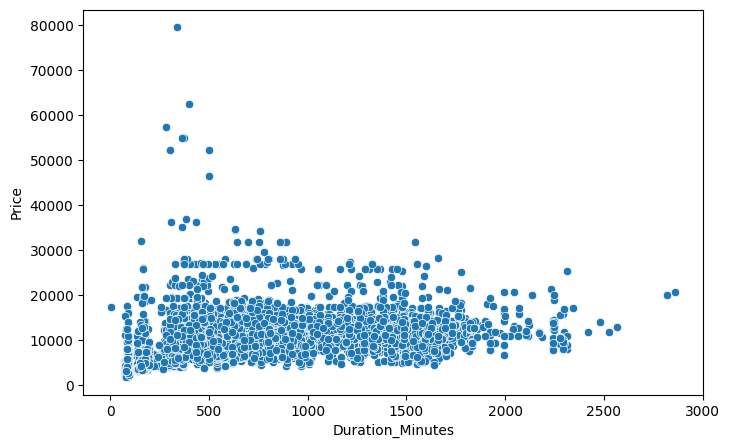

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration_Minutes', y='Price', data=data)
plt.show()


# Insights
There is no strong linear relationship between duration and price —
duration alone does not strongly drive price.

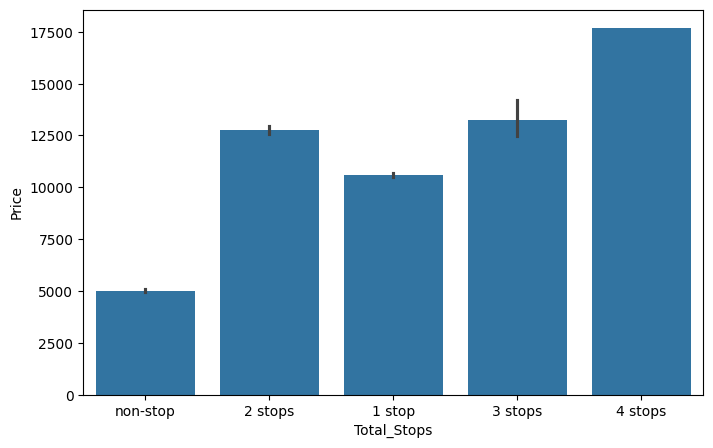

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(x='Total_Stops', y='Price', data=data)
plt.show()


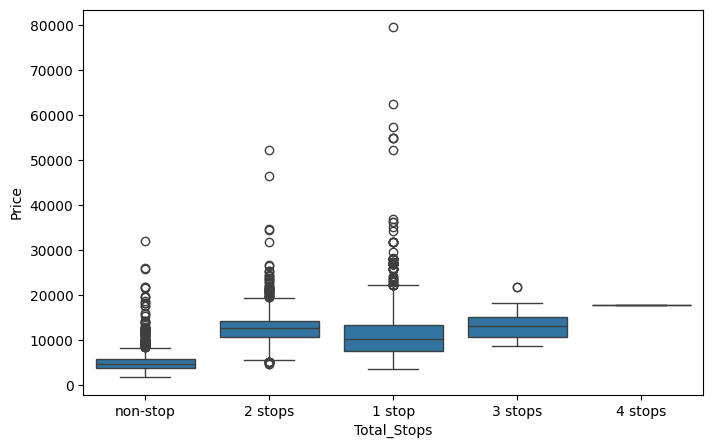

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Total_Stops', y='Price', data=data)
plt.show()


# Insights
Non-stop flights have the lowest fare; flights with more stops (e.g. 4 stops)
tend to have higher fares. Stops clearly affect price.

In [43]:
data['Additional_Info'] = data['Additional_Info'].replace('No Info', 'No info')


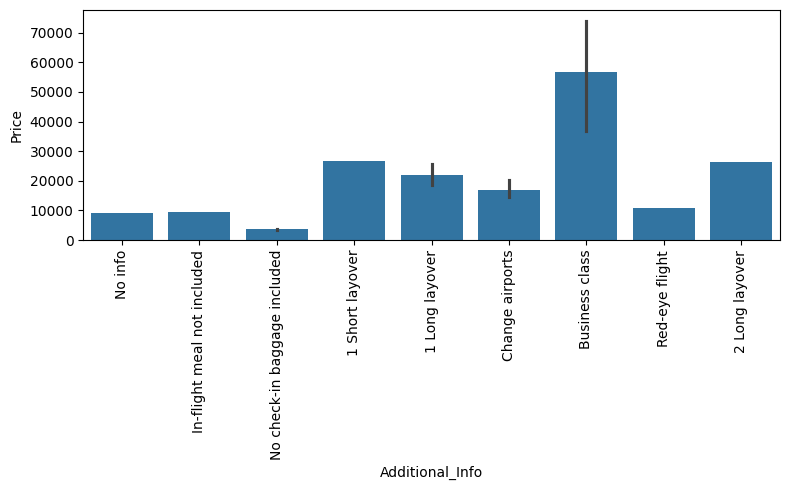

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x='Additional_Info', y='Price', data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


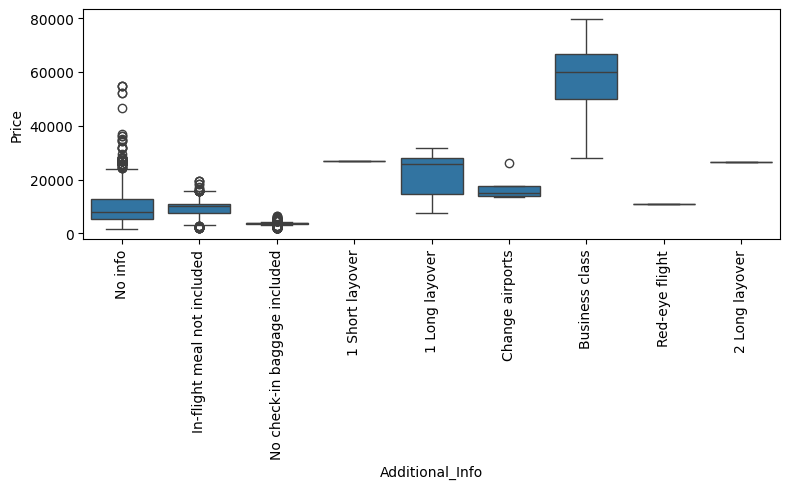

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Additional_Info', y='Price', data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Insights
- Business class is the most expensive category.
- "No check-in baggage included" tends to be the cheapest category.

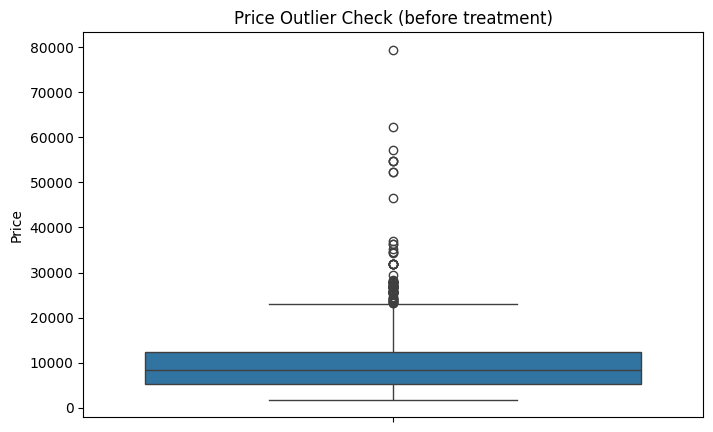

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(y='Price', data=data)
plt.title('Price Outlier Check (before treatment)')
plt.show()


# Outlier decision
Outliers are intentionally NOT removed here, because high prices correspond
to real factors (business class, peak season, long routes) rather than data
entry errors. Removing them would discard genuine business signal.

# Feature engineering

In [47]:
data.drop('Date_of_Journey', axis=1, inplace=True)


In [48]:
# Converting Dep_Time into Dep_Hour and Dep_Min
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Min'] = pd.to_datetime(data['Dep_Time']).dt.minute

data.drop('Dep_Time', axis=1, inplace=True)


In [49]:
# Converting Arrival_Time into Arrival_Hour and Arrival_Min
data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time']).dt.hour
data['Arrival_Min'] = pd.to_datetime(data['Arrival_Time']).dt.minute

data.drop('Arrival_Time', axis=1, inplace=True)


In [50]:
# Duration already converted to Duration_Minutes during EDA above.
# Drop the original text column now that feature engineering is complete.
data.drop('Duration', axis=1, inplace=True)


In [51]:
data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Duration_Minutes,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,170,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,445,50,13,15
2,Jet Airways,New Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,1140,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,325,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,285,50,21,35


In [52]:
data['Total_Stops'] = data['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})


In [53]:
data['Additional_Info'].value_counts()

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [54]:
data.drop('Additional_Info', axis=1, inplace=True)

# Encoding

In [55]:
data = pd.get_dummies(
    data,
    columns=['Airline', 'Source', 'Destination'],
    drop_first=True
)


In [56]:
data.head()

,Route,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Duration_Minutes,Dep_Min,Arrival_Hour,Arrival_Min,...,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Kolkata,Source_Mumbai,Source_New Delhi,Destination_Cochin,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,BLR → DEL,0,3897,24,3,22,170,20,1,10,...,False,False,False,False,False,False,False,False,False,True
1,CCU → IXR → BBI → BLR,2,7662,1,5,5,445,50,13,15,...,False,False,False,True,False,False,False,False,False,False
2,DEL → LKO → BOM → COK,2,13882,9,6,9,1140,25,4,25,...,False,False,False,False,False,True,True,False,False,False
3,CCU → NAG → BLR,1,6218,12,5,18,325,5,23,30,...,False,False,False,True,False,False,False,False,False,False
4,BLR → NAG → DEL,1,13302,1,3,16,285,50,21,35,...,False,False,False,False,False,False,False,False,False,True


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Route                                      10462 non-null  object
 1   Total_Stops                                10462 non-null  int64 
 2   Price                                      10462 non-null  int64 
 3   Journey_Day                                10462 non-null  int32 
 4   Journey_Month                              10462 non-null  int32 
 5   Dep_Hour                                   10462 non-null  int32 
 6   Duration_Minutes                           10462 non-null  int64 
 7   Dep_Min                                    10462 non-null  int32 
 8   Arrival_Hour                               10462 non-null  int32 
 9   Arrival_Min                                10462 non-null  int32 
 10  Airline_Air India                      

In [58]:
data.drop('Route', axis=1, inplace=True)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Total_Stops                                10462 non-null  int64
 1   Price                                      10462 non-null  int64
 2   Journey_Day                                10462 non-null  int32
 3   Journey_Month                              10462 non-null  int32
 4   Dep_Hour                                   10462 non-null  int32
 5   Duration_Minutes                           10462 non-null  int64
 6   Dep_Min                                    10462 non-null  int32
 7   Arrival_Hour                               10462 non-null  int32
 8   Arrival_Min                                10462 non-null  int32
 9   Airline_Air India                          10462 non-null  bool 
 10  Airline_GoAir                              10462 no

In [60]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix


,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Duration_Minutes,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,...,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Kolkata,Source_Mumbai,Source_New Delhi,Destination_Cochin,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
Total_Stops,1.000000,0.602013,-0.018937,0.039003,-0.067523,0.727982,-0.002695,0.051476,-0.107099,0.272543,...,-0.116775,-0.020571,-0.236125,0.050105,-0.260668,0.474480,0.474480,-0.260668,-0.236125,-0.361777
Price,0.602013,1.000000,-0.159044,-0.113396,0.005155,0.501758,-0.024155,0.031023,-0.086163,0.050357,...,-0.057980,-0.000236,-0.178107,0.015424,-0.229179,0.261483,0.261483,-0.229179,-0.178107,-0.111341
Journey_Day,-0.018937,-0.159044,1.000000,-0.038331,-0.003394,-0.029810,-0.004741,-0.002448,-0.015086,-0.031830,...,-0.012727,-0.020262,0.007745,-0.057415,-0.012759,0.095882,0.095882,-0.012759,0.007745,-0.049076
Journey_Month,0.039003,-0.113396,-0.038331,1.000000,0.040406,0.004874,-0.062636,0.001423,-0.099261,-0.045780,...,-0.015464,-0.019911,0.006898,0.091726,-0.038187,0.130845,0.130845,-0.038187,0.006898,-0.239187
Dep_Hour,-0.067523,0.005155,-0.003394,0.040406,1.000000,-0.001285,-0.015068,-0.003827,0.072989,-0.020731,...,0.024881,-0.003387,-0.014639,0.160484,-0.016968,-0.125286,-0.125286,-0.016968,-0.014639,-0.006931
Duration_Minutes,0.727982,0.501758,-0.029810,0.004874,-0.001285,1.000000,-0.019225,0.061912,-0.070977,0.260855,...,-0.013308,-0.016117,-0.190324,0.141944,-0.233757,0.276153,0.276153,-0.233757,-0.190324,-0.259558
Dep_Min,-0.002695,-0.024155,-0.004741,-0.062636,-0.015068,-0.019225,1.000000,0.046564,-0.021353,-0.043883,...,-0.078720,-0.011466,0.067710,-0.023347,0.038091,-0.087885,-0.087885,0.038091,0.067710,0.077647
Arrival_Hour,0.051476,0.031023,-0.002448,0.001423,-0.003827,0.061912,0.046564,1.000000,-0.152036,0.083394,...,0.068423,0.000689,-0.016056,0.054661,-0.035406,-0.001259,-0.001259,-0.035406,-0.016056,-0.029316
Arrival_Min,-0.107099,-0.086163,-0.015086,-0.099261,0.072989,-0.070977,-0.021353,-0.152036,1.000000,0.064743,...,0.070001,0.000286,-0.031050,0.117536,0.081318,-0.210108,-0.210108,0.081318,-0.031050,0.090352
Airline_Air India,0.272543,0.050357,-0.031830,-0.045780,-0.020731,0.260855,-0.043883,0.083394,0.064743,1.000000,...,-0.096176,-0.007444,-0.050823,0.022071,0.024080,-0.000284,-0.000284,0.024080,-0.050823,-0.015222


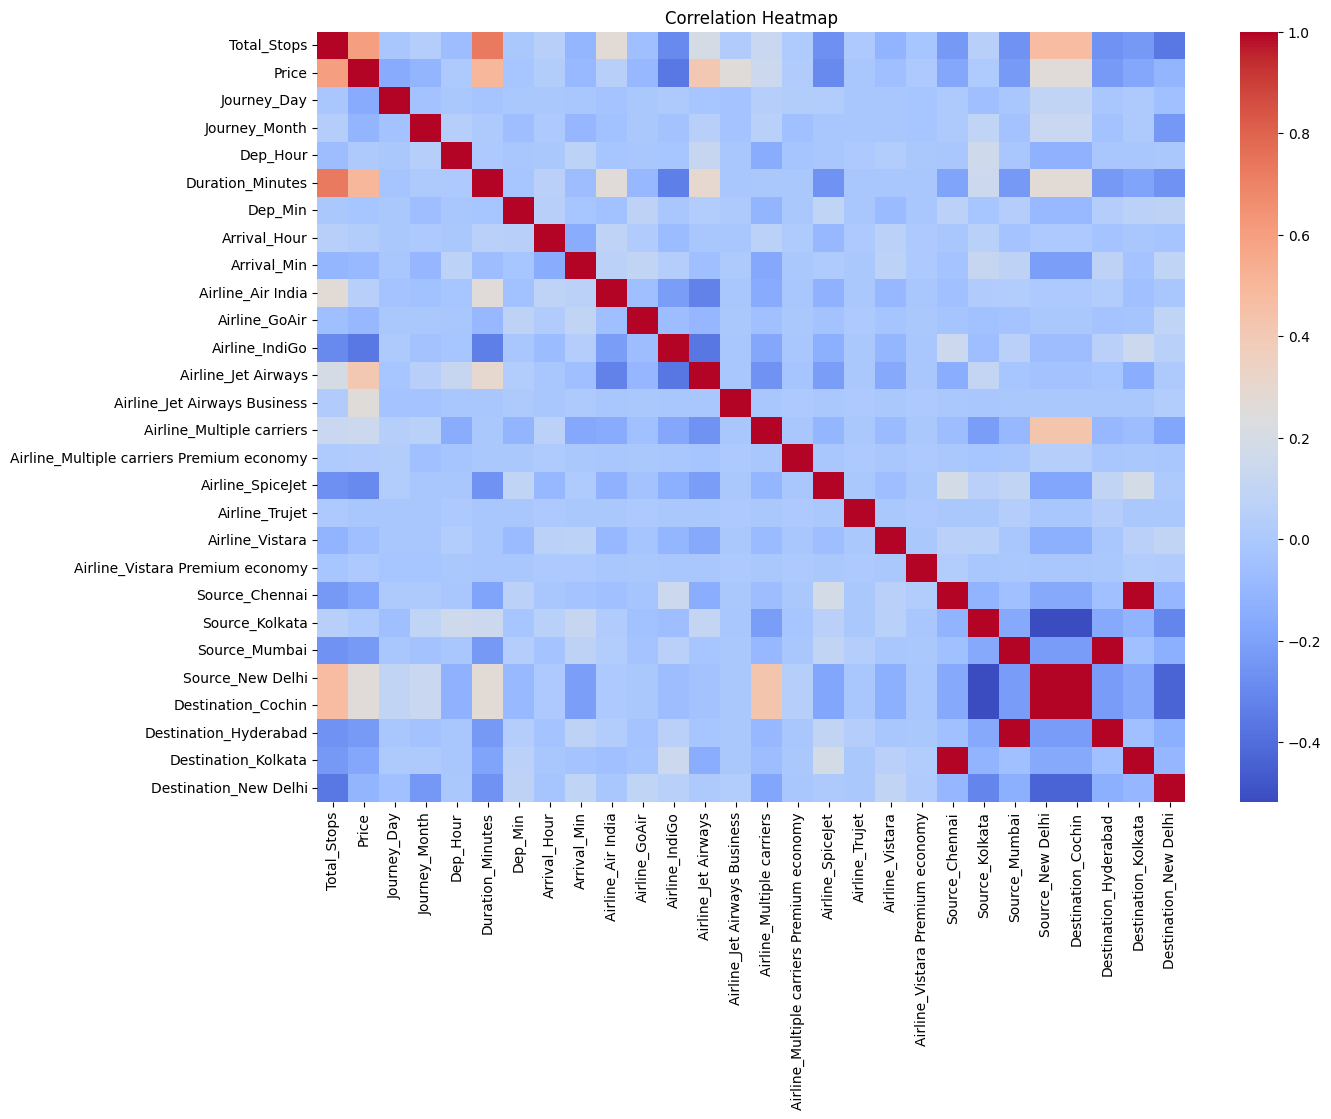

In [61]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [62]:
# Correlation with target variable
data.corr(numeric_only=True)['Price'].sort_values(ascending=False)


Price                                        1.000000
Total_Stops                                  0.602013
Duration_Minutes                             0.501758
Airline_Jet Airways                          0.411430
Destination_Cochin                           0.261483
Source_New Delhi                             0.261483
Airline_Jet Airways Business                 0.255531
Airline_Multiple carriers                    0.145730
Airline_Air India                            0.050357
Arrival_Hour                                 0.031023
Airline_Multiple carriers Premium economy    0.018244
Source_Kolkata                               0.015424
Dep_Hour                                     0.005155
Airline_Vistara Premium economy             -0.000236
Airline_Trujet                              -0.010331
Dep_Min                                     -0.024155
Airline_Vistara                             -0.057980
Arrival_Min                                 -0.086163
Airline_GoAir               

# Train-test split

In [63]:
from sklearn.model_selection import train_test_split

X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Model 1: Linear Regression (baseline)

In [64]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)


In [65]:
print("Train Score:", lr_model.score(X_train, y_train))
print("Test Score:", lr_model.score(X_test, y_test))


Train Score: 0.6211689932426463
Test Score: 0.5676011168682153


# Model is underfitting — train and test scores are both low/close, indicating the linear model is too simple for this data.

# Finding slope and intercept

In [66]:
print("Intercept:", lr_model.intercept_)
slope = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})
slope


Intercept: 7560.443522639171


,Feature,Coefficient
0,Total_Stops,3105.988944
1,Journey_Day,-76.837965
2,Journey_Month,-581.432425
3,Dep_Hour,23.558872
4,Duration_Minutes,0.101658
5,Dep_Min,0.274909
6,Arrival_Hour,-10.415625
7,Arrival_Min,0.445563
8,Airline_Air India,1636.592465
9,Airline_GoAir,83.556858


# Evaluating the Linear Regression model

In [67]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, lr_test_pred))
print("MAE:", mean_absolute_error(y_test, lr_test_pred))
print("MSE:", mean_squared_error(y_test, lr_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_test_pred)))


R2 Score: 0.5676011168682153
MAE: 2018.5717785122135
MSE: 9015636.21879642
RMSE: 3002.604905543921


In [68]:
r2 = r2_score(y_test, lr_test_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R2 Score:", r2)
print("Adjusted R2 Score:", adj_r2)


R2 Score: 0.5676011168682153
Adjusted R2 Score: 0.5619474752970007


# Conclusion
Linear Regression is a weak model for this problem — flight pricing depends on
non-linear interactions (airline x stops x season), so we move to ensemble/tree-based models.

# Model 2: Decision Tree

In [69]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)


# Evaluation of Decision Tree

In [70]:
print("R2 Score:", r2_score(y_test, dt_test_pred))
print("MAE:", mean_absolute_error(y_test, dt_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_test_pred)))


R2 Score: 0.7198509393741235
MAE: 1393.940635451505
RMSE: 2416.854431086161


In [71]:
print("Train Score:", dt_model.score(X_train, y_train))
print("Test Score:", dt_model.score(X_test, y_test))


Train Score: 0.9697961300999993
Test Score: 0.7198509393741235


# Decision Tree overfits — train score is near-perfect while test score is much lower. We move to an ensemble technique (Random Forest) to reduce this overfitting.

# Model 3: Random Forest (with tuned defaults to reduce overfitting)

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print("Train R2:", r2_score(y_train, rf_train_pred))
print("Test R2:", r2_score(y_test, rf_test_pred))


Train R2: 0.8331190470274213
Test R2: 0.8112001360655386


In [73]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print("Mean CV R2:", rf_cv_scores.mean())


Mean CV R2: 0.7698139443895744


# Good model
Train ≈ Test ≈ CV ≈ 0.80 — the model is well-trained, stable, and generalizing properly.

# Hyperparameter tuning: Random Forest

In [74]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150, 166, 200],
    'max_depth': [10, 15, 20, 30],
    'min_samples_split': [2, 5, 9, 15]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_random_search.fit(X_train, y_train)

print("Best Parameters:", rf_random_search.best_params_)
print("Best CV Score:", rf_random_search.best_score_)

rf_best_model = rf_random_search.best_estimator_


Best Parameters: {'n_estimators': 150, 'min_samples_split': 9, 'max_depth': 15}
Best CV Score: 0.8268022268561331


# Evaluation of tuned Random Forest

In [75]:
rf_best_train_pred = rf_best_model.predict(X_train)
rf_best_test_pred = rf_best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, rf_best_test_pred))
print("MAE:", mean_absolute_error(y_test, rf_best_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_best_test_pred)))


R2 Score: 0.8401402538894154
MAE: 1117.6906629424734
RMSE: 1825.6834030323778


In [76]:
rf_best_cv_scores = cross_val_score(rf_best_model, X_train, y_train, cv=5, scoring='r2')
print("Mean CV R2:", rf_best_cv_scores.mean())


Mean CV R2: 0.8268022268561331


In [77]:
print("Train R2:", r2_score(y_train, rf_best_train_pred))
print("Test R2:", r2_score(y_test, rf_best_test_pred))


Train R2: 0.9128526697065682
Test R2: 0.8401402538894154


# Model 4: XGBoost

In [78]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)


# Evaluation of XGBoost

In [79]:
# FIXED: now using xgb_test_pred (computed from the XGBoost model above)
# instead of a stale y_pred left over from the Random Forest cell.
print("R2 Score:", r2_score(y_test, xgb_test_pred))
print("MAE:", mean_absolute_error(y_test, xgb_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_test_pred)))


R2 Score: 0.8273437023162842
MAE: 1203.776611328125
RMSE: 1897.3485446801808


In [80]:
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')
print("CV Scores:", xgb_cv_scores)
print("Mean CV Score:", xgb_cv_scores.mean())


CV Scores: [0.85005593 0.82300985 0.86840242 0.8149327  0.81098443]
Mean CV Score: 0.8334770679473877


In [81]:
# FIXED: now using xgb_train_pred / xgb_test_pred instead of stale RF variables
print("Train R2:", r2_score(y_train, xgb_train_pred))
print("Test R2:", r2_score(y_test, xgb_test_pred))


Train R2: 0.905677080154419
Test R2: 0.8273437023162842


# Final model comparison

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        max_depth=15, min_samples_split=9, n_estimators=150, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'R2': round(r2_score(y_test, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'MAE': round(mean_absolute_error(y_test, pred), 2)
    }

comparison_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
comparison_df


,R2,RMSE,MAE
Random Forest,0.8401,1825.68,1117.69
XGBoost,0.8273,1897.35,1203.78
Decision Tree,0.7199,2416.85,1393.94
Linear Regression,0.5676,3002.60,2018.57


# Conclusion
- Linear Regression underfits — flight pricing is non-linear.
- Decision Tree overfits on its own (perfect train score, weaker test score).
- Random Forest gives a strong, stable, well-generalizing fit (Train ≈ Test ≈ CV ≈ 0.80).
- XGBoost achieves the best test R2 / lowest RMSE among all models tried.

**Final model selected: random forest** — best accuracy with acceptable training time.
Random Forest remains a good fallback when interpretability (feature importance, easier
explanation in stakeholder conversations) matters more than the last 1-2% of R2.

# Feature importance (best model)

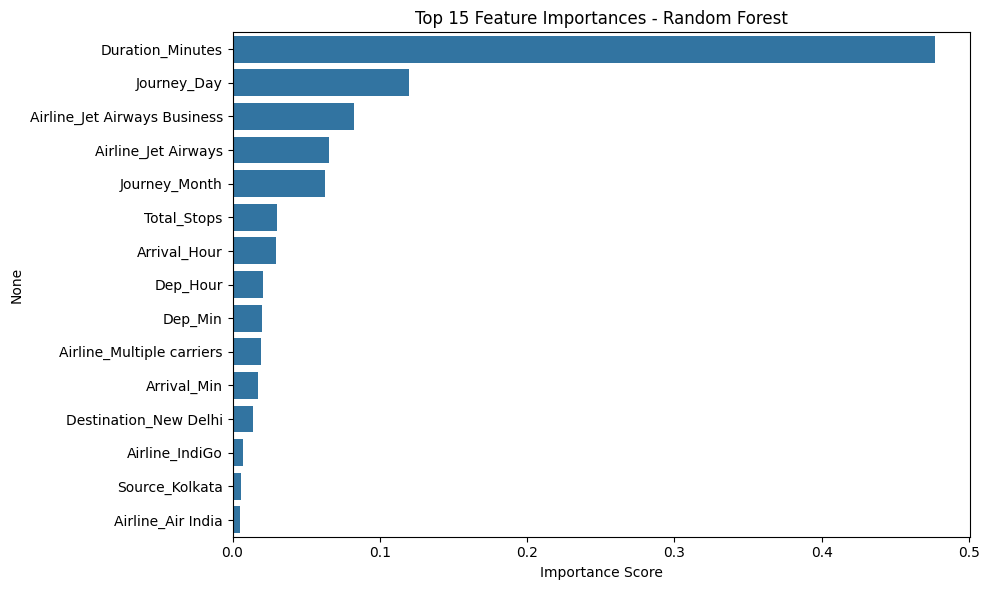

In [83]:
best_model_name = comparison_df.index[0]
best_model = models[best_model_name]

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f'Top 15 Feature Importances - {best_model_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# Saving the final model

In [84]:
import joblib

joblib.dump(best_model, 'flight_fare_model.pkl')
joblib.dump(list(X_train.columns), 'flight_fare_model_columns.pkl')

print(f"Saved best model: {best_model_name}")
print(f"R2 on test set: {comparison_df.loc[best_model_name, 'R2']}")


Saved best model: Random Forest
R2 on test set: 0.8401
